# <img src="./logo_UTN.svg" align="right" width="150" /> 

#### Teoría de Circuitos II

# Tarea Semanal 2

Autor: Lopez Cruz Juan Carlos


# Introducción

Para esta tarea se nos pide analizar el siguiente circuito:

<img src="./circuito_ts2.png" /> 

## Items a tratar del circuito:

1. Hallar la transferencia $H(s) = \frac{V_o}{V_i}$ en funcion de $\omega_0$ y Q

2. Hallar los parametros de $\omega_0$, Q y K

3. Cómo podría obtener un circuito pasabanda con los mismos componentes originales y con qué parámetros quedaría diseñado (Ver ejemplo 4.6 en Schaumann , pag. 159).

4. Se pide implementar un filtro pasabajos Chebyshev que cumpla con la siguiente plantilla. Debera interconectar mas de una red como la aquí presentada en configuración cascada. De ser necesario incluya una red de orden 1 pasabajos RC.

<img src="./plantilla_ts2.png" /> 

## Items bonus:

1.  Obtener los valores de la red normalizados en frecuencia e impedancia.
2.  Simulación en Python de la Transferencia normalizada.
3.  Simulación Circuital de la red con los valores normalizados. Simule la respuesta de modulo en forma paramétrica convenientemente para graficar curvas pasabanda con Q: 1:100 en pasos de 10.

## Resolucion:

### Calculo de la transferencia H(s) 

Primero empezaremos a calcular la funcion transferencia de nuestro circuito, para posteriormente generalizar la funcion con los parametros $\omega_0$, Q y K

In [13]:
from IPython.display import IFrame
IFrame("./transf_ts2.pdf", width=1100, height=1000)

### Verificacion de nuestra transferencia

Procederemos a verificar nuestra transfrecia mediante sympy

In [17]:
# Cargamos la libreria display para poder imprimir nuestra transferencia
from IPython.display import display, Math

# Cargamos la libreria sympy
import sympy as sp

# Declaramos la variable de laplace 's', los componentes de la red y los nodos como variables simbolicas
s = sp.symbols('s')
G1, G2, G3, G4, C = sp.symbols('G1 G2 G3 G4 C')
VB, VA, Vo = sp.symbols('VB VA Vo')
V1 = sp.symbols('V1')

# Definimos las ecuaciones
eq_1 = sp.Eq(VA, -Vo)
eq_2 = sp.Eq(VB * G3, -s * C * VA)
eq_3 = sp.Eq(V1 * G1, -VB * s * C -VB * G2 - Vo * G3)

# Cargamos las ecuaciones
sol = sp.solve([eq_1, eq_2, eq_3], [VB, VA, V1, Vo])

# Calculamos la admitancia
H = sp.simplify(Vo / sol[V1])


# Esta parte del procedimiento lo que hace es factorizar para que la s de mayor orden sea unitaria
# Guardamos el numerador y el denominador de nuestra transferencia
num, den = sp.fraction(H)

# Declaramos que sean tratados como polinomios con la variable laplaciana 's'
num_poly = sp.Poly(num, s)
den_poly = sp.Poly(den, s)

# Extraemos el coeficiente de mayor grado del numerador y del denominador
a1_num = num_poly.LC()
a1_den = den_poly.LC()

# Definimos nuestra ganancia (K)
k = a1_num/a1_den

# Procedemos a simplicar nuestra transferencia teniendo en cuenta los coeficientes extraidos
H_norm = sp.simplify(num/a1_num) / sp.simplify(den/a1_den)

# Imprimimos nuestra transferencia
display(Math("H(s) = " + sp.latex(k) + sp.latex(H_norm)))

<IPython.core.display.Math object>

Podemos apreciar que efectivamente se cumple con lo calculado anteriormente, ya que si multiplicamos por G3 tanto en el numerador como en el denominador nos queda nuetra transferencia de la siguiente forma.

\begin{equation}
H(s) = -\frac{G1}{G3}\frac{\frac{G3^2}{C^2}}{s^2 + s\frac{G2}{C} + \frac{G3^2}{C^2}} 
\end{equation}

### Obtencion de los parametros $\omega_0$, k y Q

Para este caso los parametros quedan de la siguiente manera.

1. $K = \frac{G1}{G3} \Rightarrow K = \frac{R3}{R1}$
2. $\omega_0^2 = \frac{G3^2}{C^2} \Rightarrow \omega_0^2 = \frac{1}{R3^2C^2}$
3. $\frac{\omega_0}{Q} = \frac{G2}{C} \Rightarrow \frac{\frac{1}{R3C}}{Q} = \frac{1}{R2C} \Rightarrow Q = \frac{R2}{R3}$

Por lo que nuestra transferencia quedara definida de la siguiente manera.

\begin{equation}
H(s) = \frac{-K \omega_0^2}{s^2 + s\frac{\omega_0}{Q} + \omega_0^2} 
\end{equation}

### Normalizacion de la Transferencia

Primeramente elegimos nuestra norma de frecuencia, siendo esta $\Omega_w = \omega_w = \frac{1}{R3C} = 1$, como nuetras K y Q tambien dependen de R3, elegiremo como nuestra norma de impedancia a $\Omega_z = R3 = 1$, si esto lo llevamos a nuestra norma de frecuencia nos queda que $\Omega_w = 1 = \frac{1}{C} \Rightarrow C = 1$, con estas consideraciones queda definido de la siguiente manera.

1. R3 = 1
2. C = 1
3. R1 = $\frac{1}{K}$
4. R2 = Q

Por lo que en nuestra red se ve reflejado de la siguiente manera.

In [11]:
from IPython.display import IFrame
IFrame("./red_normalizada_pasa_bajo_ts2.pdf", width=1000, height=1000)

### Simulacion de la Transferencia

Para poder simular nuestra transferecia tomaremos que $R4 = R3 = 1$, una ganancia nula por lo que $R1 = 1$ y una Q de 10 por lo que nos queda que $R2 = 10$

In [26]:
import matplotlib as mpl
from matplotlib import pyplot as plt
#%%  Inicialización de librerías
mpl.rcParams['figure.figsize'] = (10,10)

# Modificamos el largo y ancho de la salida
fig_sz_x = 14
fig_sz_y = 13
fig_dpi = 80 # dpi

# tamaño de la tipografía
fig_font_size = 11

plt.rcParams.update({'font.size':fig_font_size})

# módulos numéricos y de funciones científicas
import numpy as np
from scipy import signal as sig

# Ahora importamos las funciones de PyTC2
from pytc2.sistemas_lineales import bodePlot, pzmap, GroupDelay, analyze_sys

Ya con nuestras librerias y funciones cargadas procedemos a simular primero nuestra transferencia normalizada

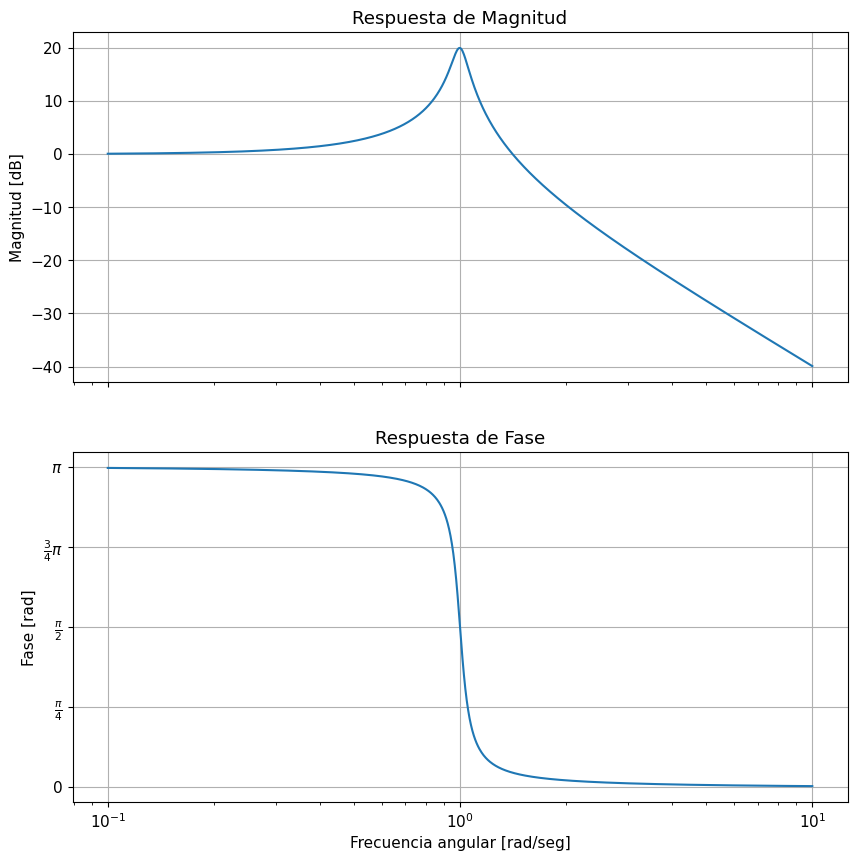

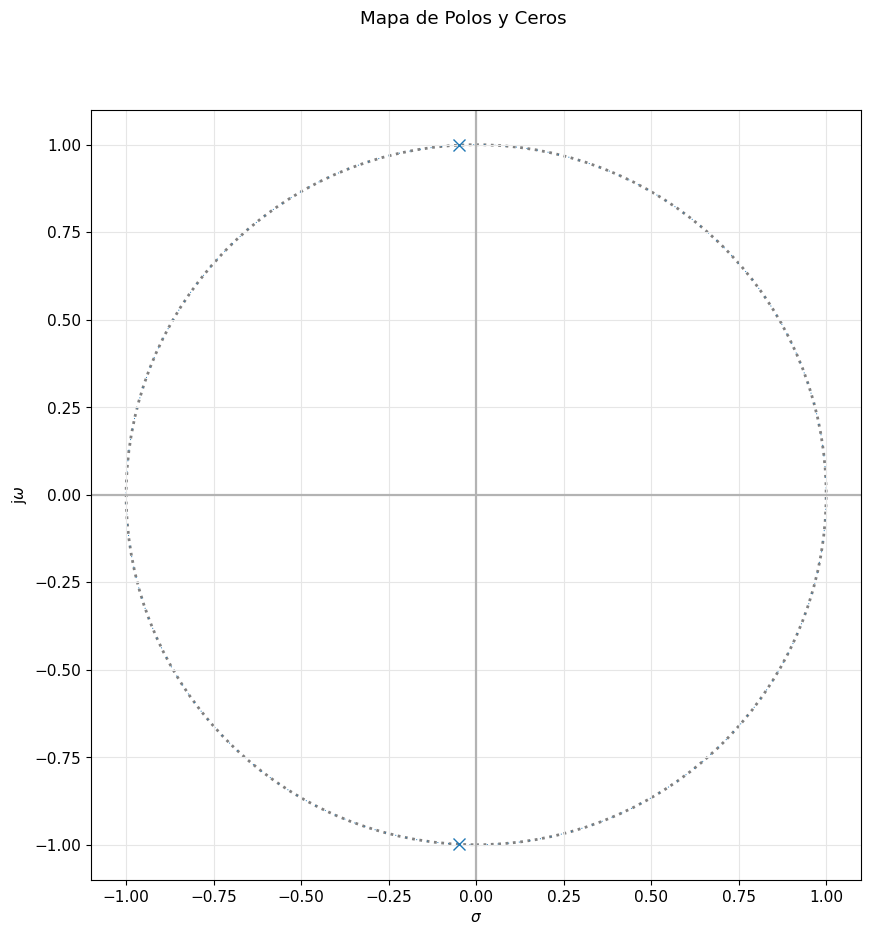

In [7]:
# Cargamos la funcion transferencia como vectores de sus coeficientes.

Q = 10
K = 1
num = np.array([ -K])
den = np.array([ 1, 1/Q, 1])

H1 = sig.TransferFunction( num, den )

# Graficamos el diagrama de polos y ceros
# Graficamos la respuesta en frecuencia para el modulo y la fase.

_, axes_hdl = bodePlot(H1)

# para que se vea como uno intuye el módulo. Probar comentar las siguientes 2 líneas
plt.sca(axes_hdl[0])
#plt.ylim([-1,1])

plt.gca

pzmap(H1)

plt.show()


Al definir una Q elevada podemos notar el realce en la grafica del modulo de nuestra transferencia y un cambio mas abrubto en la fase, ademas al ser nuestra k negativa tenemos que una inversion de $\pi$ en la grafica de la fase

### Obtencion de un circuito pasa banda

Ahora veremos la forma de obtener un circuito que sea del tipo pasa banda usando los mismos componentes, antes de comenzar el desarrollo vamos a definir que:

* $V_0 = V_L$ = Low pass (pasa bajo)

* $V_H$ = High pass (pasa alto)

* $V_B$ = Band pass (pasa banda)

Ya con esto definido empezamos nuestro desarrollo.

\begin{equation}
H(s) = \frac{V_L}{V_I} = \frac{-K \omega_0^2}{s^2 + s\frac{\omega_0}{Q} + \omega_0^2} = \frac{-K}{s^2 + s\frac{1}{Q} + 1} 
\end{equation}

\begin{equation}
V_L(s^2 + s\frac{1}{Q}) + V_L = -KV_I 
\end{equation}

\begin{equation}
sV_L(s + \frac{1}{Q}) = -(KV_I + V_L) 
\end{equation}

\begin{equation}
sV_L = -(KV_I + V_L)\frac{1}{(s + \frac{1}{Q})}
\end{equation}

Aqui definimos a $V_B = -(KV_I + V_L)\frac{1}{(s + \frac{1}{Q})}$, por lo que nos queda de la siguiente forma.

\begin{equation}
V_B = V_B\frac{1}{s}
\end{equation}

Volvemos a la ecuacion de $V_B$.

\begin{equation}
V_B = -(KV_I + V_L)\frac{1}{(s + \frac{1}{Q})} \Rightarrow sV_B + V_B\frac{1}{Q}= -(KV_I + V_L)
\end{equation}

\begin{equation}
\Rightarrow sV_B= -(KV_I + V_L + V_B\frac{1}{Q})
\end{equation}

Aqui definimos a $V_H = (KV_I + V_L + V_B\frac{1}{Q})$, por lo que nos queda de la siguiente forma.

\begin{equation}
\Rightarrow V_B= -V_H\frac{1}{s}
\end{equation}

De las ecuaciones obtenidas tenemos las definiciones.

* $V_H = KV_I + V_L + V_B\frac{1}{Q}$

* $V_B = -\frac{1}{s}V_H$

* $V_L = V_B\frac{1}{s}$

A continuacion se refleja lo desspejado en un esquema conceptual

<img src="./esquema_conceptual.png" /> 

Como se puede obesarvar del analisis efectudao si quiero obtener una transferencia del tipo pasa banda con el mismo circuito, solo hace falta salir por la terminal $V_B$, ahora procederemos a calcular la transferencia pasa banda: $H_B(s) = \frac{V_B}{V_I}$

$$
V_A G4 = -V_L G4 
\;\Rightarrow\; 
V_A = -V_L \quad (1)
$$

$$
V_B G3 = -V_A sC 
\;\Rightarrow\; 
V_B G3 = V_L sC 
\;\Rightarrow\;
V_L = V_B \frac{G3}{sC} \quad (2)
$$

$$
V_i G1 = -V_B sC - V_B G2 - V_L G3 \quad (3)
$$

Reemplazando (2) en (3):

$$
V_i G1 = -V_B sC - V_B G2 - V_B \frac{G3^2}{sC}
$$

$$
V_i G1 = -V_B \left( sC + G2 + \frac{G3^2}{sC} \right)
$$

$$
V_i G1 = -V_B \left( \frac{s^2 C^2 + sC G2 + G3^2}{sC} \right)
$$

Por lo tanto nuestra transferecnia queda de la siguiente forma.

$$
H_B(s) = \frac{V_B}{V_i} = -\frac{sC G1}{s^2 C^2 + sC G2 + G3^2}
$$

$$
H_B(s) = -\frac{G1}{C}\frac{s}{s^2 + s\frac{G2}{C} + \frac{G3^2}{C^2}}
$$

$$
H_B(s) = -\frac{G1}{G2}\frac{s\frac{G2}{C}}{s^2 + s\frac{G2}{C} + \frac{G3^2}{C^2}}
$$

Para este caso los parametros quedan de la siguiente manera.

1. $K = \frac{G1}{G2} \Rightarrow K = \frac{R2}{R1}$
2. $\omega_0^2 = \frac{G3^2}{C^2} \Rightarrow \omega_0^2 = \frac{1}{R3^2C^2}$
3. $\frac{\omega_0}{Q} = \frac{G2}{C} \Rightarrow \frac{\frac{1}{R3C}}{Q} = \frac{1}{R2C} \Rightarrow Q = \frac{R2}{R3}$

Por lo que nuestra transferencia quedara definida de la siguiente manera.

\begin{equation}
H(s) = \frac{-K s\frac{\omega_0}{Q}}{s^2 + s\frac{\omega_0}{Q} + \omega_0^2} 
\end{equation}

### Normalizacion la transferencia pasa banda

Primeramente elegimos nuestra norma de frecuencia, siendo esta $\Omega_w = \omega_w = \frac{1}{R3C} = 1$, como nuetra Q y $\frac{\omega_w}{Q}$ tambien dependen de R3, elegiremos esta como nuestra norma de impedancia a $\Omega_z = R3 = 1$, si esto lo llevamos a nuestra norma de frecuencia nos queda que $\Omega_w = 1 = \frac{1}{C} \Rightarrow C = 1$, con estas consideraciones queda definido de la siguiente manera.

1. R3 = 1
2. C = 1
3. R1 = $\frac{Q}{K}$
4. R2 = Q

### Simulacion de la Transferencia

Para poder simular nuestra transferecia tomaremos que $R4 = R3 = 1$, una ganancia nula por lo que $R1 = 1$ y una K y una Q de 1 por lo que nos queda que $R2 = R1 = Q = 1$

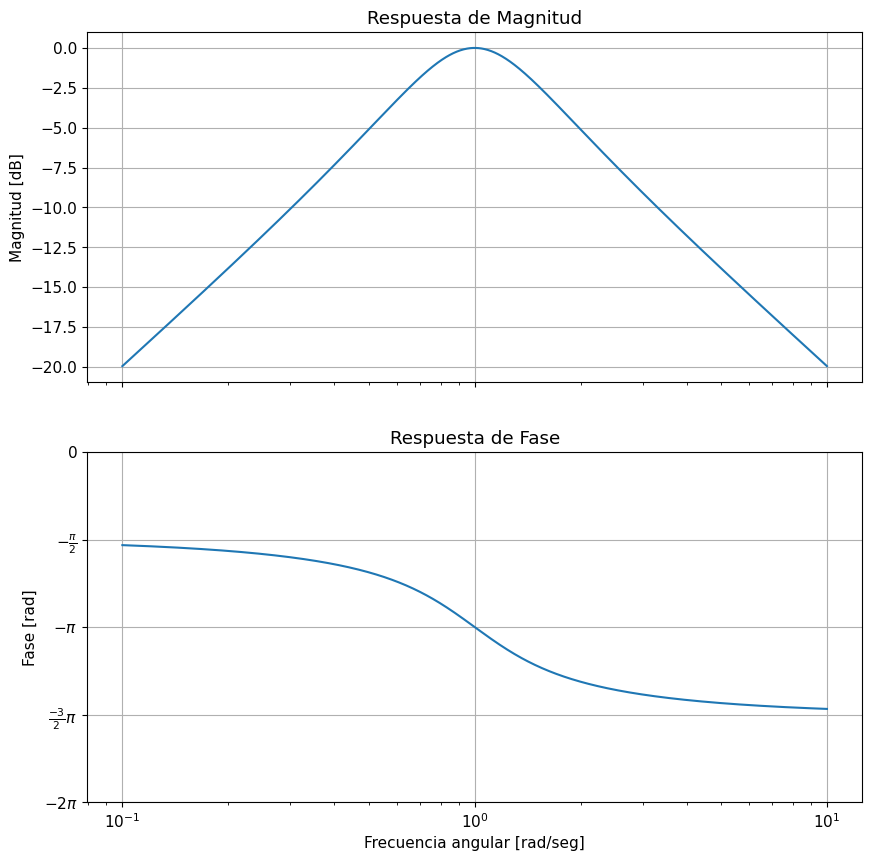

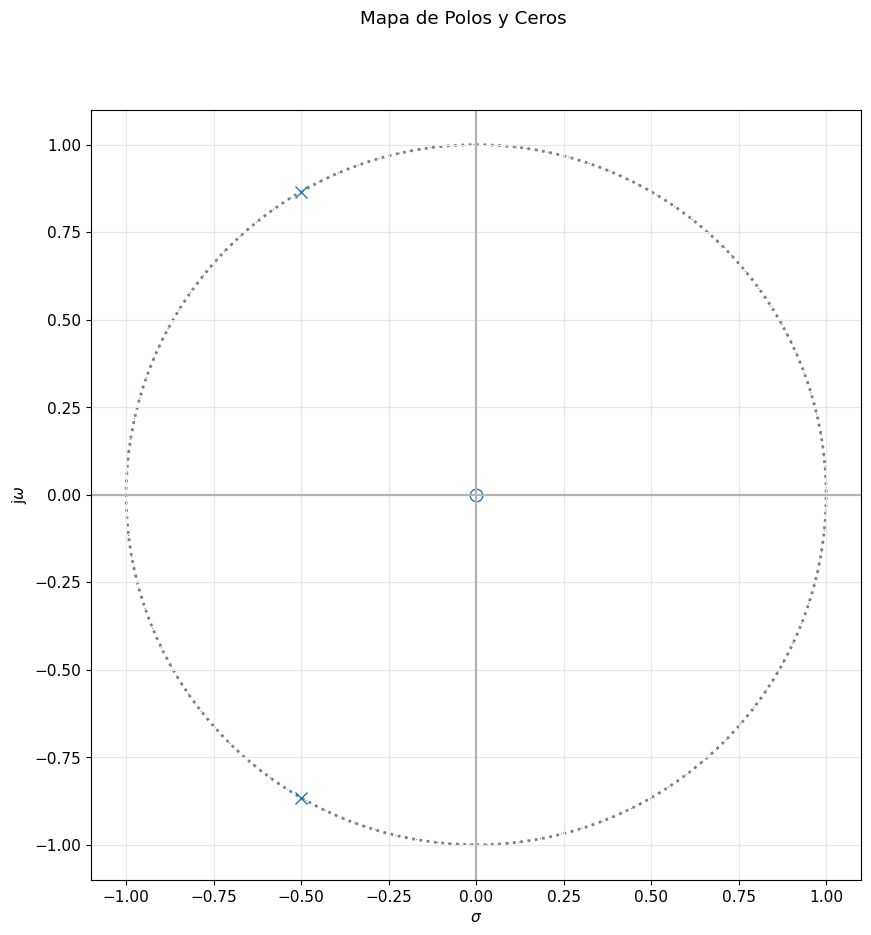

In [30]:
# Cargamos la funcion transferencia como vectores de sus coeficientes.

Q = 1
K = 1
num = np.array([ -K*(1/Q), 0])
den = np.array([ 1, 1/Q, 1])

H1 = sig.TransferFunction( num, den )

# Graficamos el diagrama de polos y ceros
# Graficamos la respuesta en frecuencia para el modulo y la fase.

_, axes_hdl = bodePlot(H1)

# para que se vea como uno intuye el módulo. Probar comentar las siguientes 2 líneas
plt.sca(axes_hdl[0])
#plt.ylim([-1,1])

plt.gca

pzmap(H1)

plt.show()

### Simulacion LTspice con valores variados de Q

Examinaremos como se comporta nuestra transferencia ante variaciones de Q, para esta simulacion se tendra en cuenta que K es igual a 1 y $\omega_0 = 1$

<img src="./Simulacion_LTSpice_pasa_banda.png" />
<img src="./grafica_pasa_banda.png" /> 

Podemos notar que a medida que subimos el Q tambien bajamos nuestro ancho de banda permitido, lo cual a su vez nos da una fase mas abruta.

### Plantilla pasa bajos con chebyshev

<img src="./plantilla_ts2.png" /> 

Primero empezamos por normalizar nuestra plantilla tomando como norma $\Omega = 2\pi f_p$ quedando asi nuestra $\omega_p = 1$ y $\omega_s = \frac{f_s}{f_p} = 3$, ya con nuestra plantilla normalizada procedemos a encontrar $\epsilon$ ( factor de ripple ) y n ( orden).

$$
\alpha_{\text{max}} = -20 \log \left( \frac{1}{\sqrt{1 + \xi^2 \, \omega_p^{2n}}} \right)
$$

Si $\omega = \omega_p = 1$:

$$
\alpha_{\text{max}} = -20 \log \left( \frac{1}{\sqrt{1 + \xi^2}} \right) = -20 \left( -\frac{1}{2} \log(1 + \xi^2) \right)
$$

$$
\alpha_{\text{max}} = 10 \log(1 + \xi^2)
$$

Como nuestra $\alpha_{\text{max}} = 0.4$ nos queda que $\xi^2 = 10^{0.1\alpha_{\text{max}}} - 1 = 10^{0.1*0.4} - 1 = 0.096$, por lo tanto nos queda que

$$
\xi = \sqrt{0.096} = 0.31
$$

Ahora calcularemos n.

$$
\alpha_{\min} = 10 \log \left(1 + \xi^2 \cosh^2\left(n \cosh^{-1}(w)\right)\right)
$$

$$
\frac{\alpha_{\min}}{10} = \log \left(1 + \xi^2 \cosh^2\left(n \cosh^{-1}(w)\right)\right)
$$

$$
10^{\frac{\alpha_{\min}}{10}} = 1 + \xi^2 \cosh^2\left(n \cosh^{-1}(w)\right)
$$

$$
10^{\frac{\alpha_{\min}}{10}} - 1 = \xi^2 \cosh^2\left(n \cosh^{-1}(w)\right)
$$

$$
\frac{10^{\frac{\alpha_{\min}}{10}} - 1}{\xi^2} = \cosh^2\left(n \cosh^{-1}(w)\right)
$$

$$
\sqrt{\frac{10^{\frac{\alpha_{\min}}{10}} - 1}{\xi^2}} = \cosh\left(n \cosh^{-1}(w)\right)
$$

$$
\cosh^{-1}\left(\sqrt{\frac{10^{\frac{\alpha_{\min}}{10}} - 1}{\xi^2}}\right) = n \cosh^{-1}(w)
$$

$$
n = \frac{\cosh^{-1}\left(\sqrt{\frac{10^{\frac{\alpha_{\min}}{10}} - 1}{\xi^2}}\right)}{\cosh^{-1}(w)}
$$

Como sabemos que $\xi^2 = 10^{0.1\alpha_{\text{max}}} - 1$ nos queda de la siguiente manera

$$
n = \frac{\cosh^{-1}\left(\sqrt{\frac{10^{0.1\alpha_{\min}} - 1}{10^{0.1\alpha_{\text{max}}} - 1}}\right)}{\cosh^{-1}(w)}
$$

Ya con la formula despejada solo nos queda reemplazar los valores.

$$
n = \frac{\cosh^{-1}\left(\sqrt{\frac{10^{0.1\cdot48dB} - 1}{10^{0.1\cdot0.4dB} - 1}}\right)}{\cosh^{-1}(3)}
$$

$$
n = 4.19
$$

Como n = 4.19 tiene que ser un numero natural, redondeamos para arriba para asi cumplir con la condicion de la plantilla, por lo que nos queda que n = 5.

### Obtencion de la transferencia normalizada

Para este desarrollo tendremos en cuenta la siguiente identidad:

$$
\left| T(j\omega) \right|^2 = T(j\omega) \cdot T(-j\omega) = T(s) \cdot T(-s)\big|_{s = j\omega}
$$

Ya con esto definido empezamos nuestro desarrollo.

$$
|H(j\omega)|^2 = H(j\omega)\cdot H(-j\omega) = H(s)H(-s)
$$

$$
|H(j\omega)|^2 = \frac{1}{1 + \xi^2 C_n^2(\omega)}
$$

Para trabajar con el polinomio de Chebishev sabemos que $C_n^2(\omega) = 2\omega C_{n-1}(\omega) - C_{n-2}(\omega)$ donde $C_0(\omega) = 1$ y $C_1(\omega) = \omega$, con esto procedemos a calcular el polinomio de Chebyshev

$$
C_2(\omega) = 2\omega^2 - 1
$$

$$
C_3(\omega) = 2\omega(2\omega^2 -1) - \omega = 4\omega^3 - 3\omega
$$

$$
C_4(\omega) = 2\omega(4\omega^3 -3\omega) - (2\omega^2 -1)
$$

$$
C_4(\omega) = 8\omega^4 - 8\omega^2 + 1
$$

$$
C_5(\omega) = 2\omega(8\omega^4 - 8\omega^2 +1) - (4\omega^3 -3\omega)
$$

$$
C_5(\omega) = 16\omega^5 - 20\omega^3 + 5\omega
$$

Ahora sustituimos lo obtenido

$$
|H(j\omega)|^2 = \frac{1}{1 + \xi^2 (16\omega^5 - 20\omega^3 + 5\omega)^2}
$$

$$
|H(j\omega)|^2 =\frac{1}{1 + \xi^2 \left(256\omega^{10} - 640\omega^8 + 560\omega^6 - 200\omega^4 + 25\omega^2\right)}
$$

Como $\omega = \frac{s}{j}$ nos queda que:

$$
|T(s)|^2 = \frac { -\frac {1} {\epsilon^2 * 256} } { s^{10} + 2.5s^8 + \frac{35}{16} s^6 + \frac{25}{32} s^4 + \frac{25}{216} s^2 - \frac {1} {\epsilon^2 * 256}}
$$

Ahora usaremo python para calcular las raices de nuestra transferencia

In [4]:
# Módulos numéricos y de funciones científicas
import numpy as np
from scipy import signal as sig
import sympy as sp
from IPython.display import display, Math

# Módulos para los gráficos
import matplotlib as mpl
from matplotlib import pyplot as plt

# Funciones de PyTC2
from pytc2.sistemas_lineales import bodePlot, pzmap, GroupDelay, analyze_sys

In [8]:
#Epsilon
eps=np.sqrt(10**(0.4/10)-1)

#Raices
raices = np.roots([1,0,5/2,0,35/16,0,25/32,0,25/256,0,-1/((eps**2)*256)])
roots = raices[np.real(raices) < 0]

#Coeficientes
coeff = np.poly(roots)
coeff = np.round(coeff,4)

k = np.sqrt(1/((eps**2)*(16**2)))
k = np.round(k,4)

#Variable "S"
s = sp.symbols('s')

#Transferencia de quinto orden
den = sp.Poly(coeff,s)
Ts  = sp.simplify(k) / sp.simplify(den)

display(Math(r'T(s) = ' + sp.latex(Ts)))

<IPython.core.display.Math object>

Podemos observar que para construir nuestra transferecia usaremos 2 secciones de segundo orden y una de primer orden, por loq ue procedemos a calcular los polos de nuestra transferecia.

In [10]:
#Redondeo a 4 decimales
roots = np.round(roots,4)

#Muestro los polos
for i, r in enumerate(roots):
    print(f"Polo {i+1} = {r.real} + {r.imag}")

Polo 1 = -0.1193 + 1.0195
Polo 2 = -0.1193 + -1.0195
Polo 3 = -0.3124 + 0.6301
Polo 4 = -0.3124 + -0.6301
Polo 5 = -0.3861 + 0.0


Con los polos podemos obetener los coef de cada seccion de nuestra transferencia

In [13]:
#Coeficientes de las secciones
pol1 = np.array([roots[0], roots[1]])
pol2 = np.array([roots[2], roots[3]])
pol3 = roots[4]

print(np.round(np.poly(pol1),4))
print(np.round(np.poly(pol2),4))
print(np.abs(pol3))

[1.     0.2386 1.0536]
[1.     0.6248 0.4946]
0.3861


Una vez calculado nuestro coef. de nuetra transfereciaprocedemos a armar la misma.

$$
T(s)= \frac{1}{s+0.3861} \frac{K_1\cdot1.0536}{s^2 + 0.2386s + 1.0536} \frac{K_2\cdot0.4946}{s^2 + 0.6248s + 0.4946}
$$

Ahora procedemos a calcular las ganancias de cada seccion de segundo orden.

$$
(K_1\cdot1.0536)\cdot(K_2\cdot0.4946) = 0.2012
$$

Donde si definimos a $K_2 = \frac{K_1}{2}$ nos queda de la siguiente manera.

$$
(K_1\cdot1.0536)\cdot(\frac{K_1}{2}\cdot0.4946) = 0.2012
$$

$$
\frac{K_1^2}{2}\cdot0.5211 = 0.2012
$$

Despejando nos queda que:

* $K_1 = 0.8787$
* $K_2 = 0.43935$

Ahora reemplazamos las ganancias calculadas en nuestra transferencia.

$$
T(s)= \frac{1}{s+0.3861} \frac{0.8787\cdot1.0536}{s^2 + 0.2386s + 1.0536} \frac{0.43935\cdot0.4946}{s^2 + 0.6248s + 0.4946}
$$

### Verificacion de la plantilla

Procedemos a verificar la transferencia obtenida

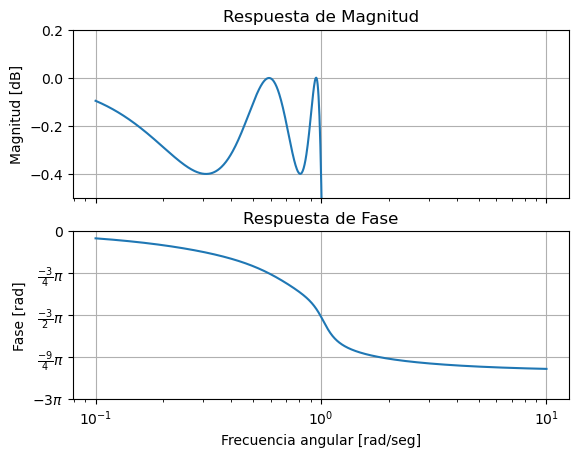

In [21]:
#Secciones
H1=sig.TransferFunction(0.8787*1.0536,np.poly(pol1))
H2=sig.TransferFunction(0.43935*0.4946,np.poly(pol2))
H3=sig.TransferFunction(1,[1,np.abs(pol3)])

#Numerador y denominador total
num = np.polymul(np.polymul(H1.num, H2.num), H3.num)
den = np.polymul(np.polymul(H1.den, H2.den), H3.den)

#Función trasnferencia
TS=sig.TransferFunction(num,den)

#Diagrama de bode
_, axes = bodePlot(TS)
axes[0].set_ylim(-0.5,0.2)
plt.show()

Podemos observar que nuestra transferencia oscila entre 0 y -4dB alo largo de la banda de paso

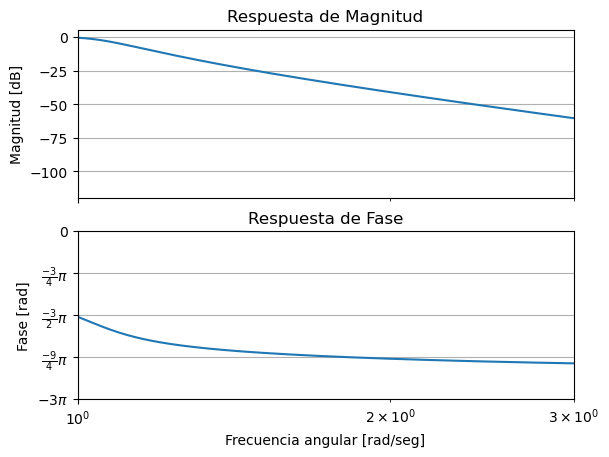

In [24]:
#Diagrama de bode
_, axes = bodePlot(TS)
axes[0].set_xlim(1,3)
plt.show()

Vemos también que para $\omega = 3$ hubo una caida mayor a 48dB por lo que se cumple la atenuacion minima para el inicio de la banda de stop.